# xgboost


## 1.import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

## 2.load data from preprocessing module

In [2]:
from preprocessing_22 import load_data_unscaled

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    feature_names
) = load_data_unscaled()

### 3 train xgboost

In [3]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 4.predictions

In [4]:
# validation predictions
y_val_pred = xgb.predict(X_val)

print(
    "Validation Accuracy:",
    accuracy_score(y_val, y_val_pred)
)

Validation Accuracy: 0.845065832355625


In [5]:
# test predictions
y_pred = xgb.predict(X_test)

y_prob = xgb.predict_proba(X_test)[:, 1]

### 5.metrics

In [6]:
# evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

Accuracy : 0.8427
Precision: 0.7905
Recall   : 0.7343
F1 Score : 0.7614
ROC AUC  : 0.9105


In [7]:
# classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.90      0.88     80802
           1       0.79      0.73      0.76     41934

    accuracy                           0.84    122736
   macro avg       0.83      0.82      0.82    122736
weighted avg       0.84      0.84      0.84    122736



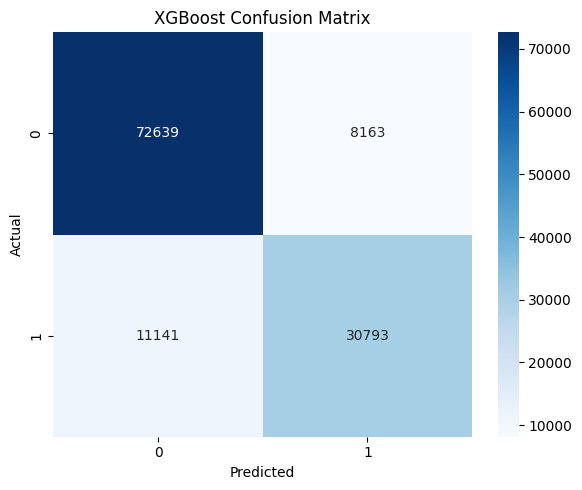

In [8]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../results/plots/xgb_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

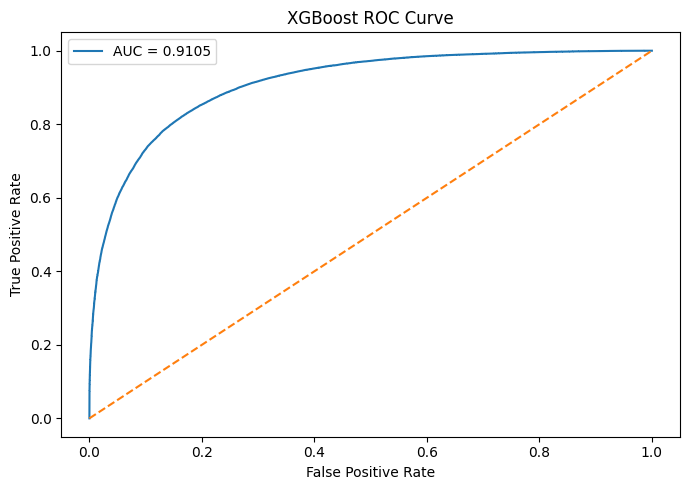

In [9]:
# ROC curve 
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/plots/xgb_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# feature importance
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1,DER_mass_transverse_met_lep,0.185766
0,DER_mass_MMC,0.168156
2,DER_mass_vis,0.089303
13,PRI_tau_pt,0.067441
11,DER_met_phi_centrality,0.063842
4,DER_deltaeta_jet_jet,0.059842
12,DER_lep_eta_centrality,0.040400
7,DER_deltar_tau_lep,0.039877
22,PRI_jet_num,0.035511
19,PRI_met,0.022092


In [11]:
joblib.dump(
    xgb,
    "../models/higgs_xgboost.pkl"
)

print("XGBoost model saved.")

XGBoost model saved.


# 6.overfitting test

In [12]:
# accuracy comparison on train, validation, and test sets
from sklearn.metrics import accuracy_score

train_pred = xgb.predict(X_train)
val_pred = xgb.predict(X_val)
test_pred = xgb.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Train Accuracy:      {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")

Train Accuracy:      0.8514
Validation Accuracy: 0.8451
Test Accuracy:       0.8427


In [13]:
# AUC comparison on train, validation, and test sets
from sklearn.metrics import roc_auc_score

train_prob = xgb.predict_proba(X_train)[:, 1]
val_prob = xgb.predict_proba(X_val)[:, 1]
test_prob = xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_prob)
val_auc = roc_auc_score(y_val, val_prob)
test_auc = roc_auc_score(y_test, test_prob)

print(f"Train AUC:      {train_auc:.4f}")
print(f"Validation AUC: {val_auc:.4f}")
print(f"Test AUC:       {test_auc:.4f}")

Train AUC:      0.9217
Validation AUC: 0.9140
Test AUC:       0.9105


In [14]:
# learning curve
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="auc",
    random_state=42
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


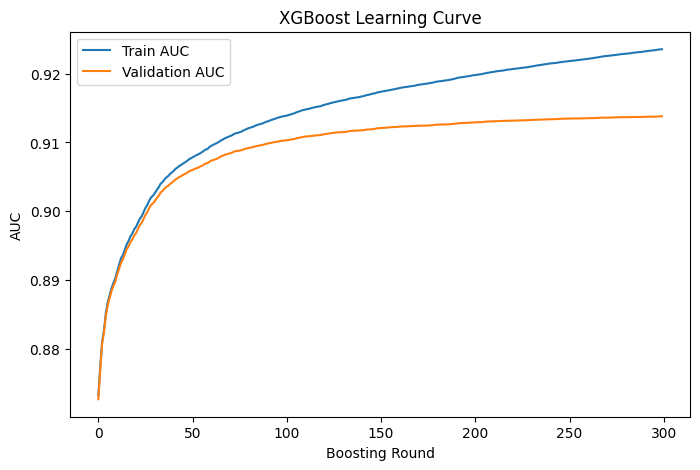

In [15]:
# extract training history
results = xgb.evals_result()

train_auc = results["validation_0"]["auc"]
val_auc = results["validation_1"]["auc"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_auc, label="Train AUC")
plt.plot(val_auc, label="Validation AUC")

plt.xlabel("Boosting Round")
plt.ylabel("AUC")
plt.title("XGBoost Learning Curve")

plt.legend()
plt.show()